# 02_MongoDB_Business_Case_Study

# Business Analytics Using MongoDB

**Course:** NoSQL Databases

**Notebook:** 02

**Database:** MongoDB Community Edition (Local)

**Dataset:** sample_supplies

**Author:** Department of Computer Science & Engineering (AI)

---

## Case Study Overview

Modern organizations generate massive amounts of operational and transactional data every day. Extracting meaningful insights from this data is essential for making informed business decisions.

In this case study, we will analyze a retail sales dataset using **MongoDB Community Edition** and the **MongoDB Aggregation Framework**. Instead of focusing on database administration or CRUD operations, this notebook emphasizes **Business Analytics**, **Business Intelligence**, and **Data Storytelling**.

Throughout this notebook, we will answer real-world business questions using MongoDB queries and aggregation pipelines. Each analysis will be accompanied by visualizations and business interpretations to demonstrate how MongoDB can be used as a powerful analytical database.

All examples in this notebook are executed using a **local MongoDB Community Server**, ensuring that the notebook can be completed completely offline.

# Business Scenario

Imagine you have been hired as a **Business Intelligence Analyst** for a multinational office supplies retailer.

The company records every sales transaction in MongoDB. Management wants to analyze this data to answer questions such as:

- Which stores generate the highest revenue?
- Which products are sold the most?
- Which customers are the most valuable?
- What purchasing methods are preferred by customers?
- How do sales change over time?
- Which business areas require improvement?

Your role is to analyze the sales data, generate business insights, and provide recommendations that support strategic decision-making.

# About the Dataset

This notebook uses the **sample_supplies** dataset.

The dataset represents sales transactions of an office supplies retailer. Each document corresponds to a single sales transaction and contains information about:

- Customer details
- Purchased products
- Quantity purchased
- Product price
- Store location
- Purchase method
- Coupon usage
- Sale date

Unlike relational databases, all related information is stored together inside a single MongoDB document, making it highly suitable for analytical workloads involving semi-structured data.

# Business Objectives

The primary objectives of this case study are to:

- Analyze retail sales transactions using MongoDB.
- Understand customer purchasing behavior.
- Evaluate store performance.
- Identify top-selling products.
- Analyze revenue trends over time.
- Generate actionable business insights.
- Support data-driven decision making using MongoDB.

# Learning Objectives

After completing this notebook, you will be able to:

- Connect Python applications to MongoDB Community Edition.
- Analyze business data stored as MongoDB documents.
- Use the MongoDB Aggregation Framework for business reporting.
- Perform descriptive and analytical reporting using PyMongo.
- Execute equivalent analytical queries using mongosh.
- Visualize business metrics using Python.
- Interpret analytical results and derive business recommendations.

# Why MongoDB for Business Analytics?

Although MongoDB is widely recognized as a NoSQL database, it is also an excellent platform for business analytics because it provides:

- Flexible document-oriented data model
- Powerful Aggregation Framework
- High-performance indexing
- Efficient querying of nested documents and arrays
- Horizontal scalability for large analytical workloads
- Seamless integration with Python for data science and business intelligence

These capabilities allow organizations to analyze operational data without requiring complex relational schemas or expensive data transformations.

# Notebook Roadmap

This notebook is organized into the following sections:

1. Introduction
2. Environment Setup
3. Loading the Sample Dataset
4. Understanding the Document Structure
5. Basic Business Analytics
6. Intermediate Aggregation
7. Advanced Aggregation
8. Performance Optimization
9. Data Visualization
10. Business Insights & Recommendations
11. Executive Summary

Each business problem in this notebook follows a consistent structure:

- **Question**
- **Business Objective**
- **PyMongo Solution**
- **Equivalent mongosh Solution**
- **Explanation**
- **Business Insight**
- **Visualization**

This structure mirrors how Business Intelligence reports are developed in real-world organizations.

# 2. Environment Setup

Before performing business analytics, we need to configure our Python environment and establish a connection with the **MongoDB Community Server** running locally.

This notebook uses:

- **MongoDB Community Edition**
- **Local MongoDB Server**
- **PyMongo** for Python connectivity
- **mongosh** for equivalent MongoDB Shell commands

Throughout this notebook, every operation performed using **PyMongo** will also be shown using its **equivalent mongosh command**.

## Import Required Python Libraries

The following libraries will be used throughout this notebook.

| Library | Purpose |
|----------|---------|
| pymongo | Connect to MongoDB |
| pandas | Data manipulation and analysis |
| numpy | Numerical computations |
| matplotlib | Data visualization |
| seaborn | Statistical visualization |
| pprint | Pretty printing MongoDB documents |

In [24]:
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pprint import pprint

## Configure Notebook Settings

Configure Pandas and Matplotlib for better readability of tables and charts.

In [25]:
# Pandas Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# Matplotlib
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120

# Seaborn Theme
sns.set_theme(style="whitegrid")

## Connect to MongoDB Community Server

Create a connection to the local MongoDB server.

Connection String:

```
mongodb://localhost:27017
```

In [26]:
client = MongoClient("mongodb://localhost:27017")

## Verify MongoDB Connection

Before performing any analysis, verify that the MongoDB server is running and accepting client requests.

In [27]:
client.admin.command("ping")

{'ok': 1.0}

## Display MongoDB Server Information

Let's verify the MongoDB server version.

In [28]:
server_info = client.server_info()

print("MongoDB Version :", server_info["version"])

MongoDB Version : 8.3.4


## Display Available Databases

The following command lists all databases available in the local MongoDB server.

In [29]:
client.list_database_names()

['admin', 'bank', 'config', 'ecommerce', 'local', 'sample_supplies']

## Connect to the Business Database

The business analytics in this notebook will use the **sample_supplies** database.

In [30]:
db = client["sample_supplies"]

## Display Available Collections

Let's inspect the collections available in the **sample_supplies** database.

In [31]:
db.list_collection_names()

['sales']

## Connect to the Sales Collection

In [32]:
sales = db["sales"]

## Verify the Collection

Before beginning the business analysis, let's verify that the sales collection contains data.

In [33]:
print("Database :", db.name)
print("Collection :", sales.name)
print("Total Documents :", sales.count_documents({}))

Database : sample_supplies
Collection : sales
Total Documents : 5000


## Section Summary

In this section, we successfully:

- Connected to the local MongoDB Community Server.
- Verified the MongoDB server status.
- Checked the MongoDB server version.
- Listed the available databases.
- Connected to the **sample_supplies** database.
- Listed the available collections.
- Connected to the **sales** collection.
- Verified that the collection contains business transaction data.

The environment is now ready for business analytics using MongoDB.

# 3. Understanding the Dataset

Before performing any business analysis, it is important to understand how the data is organized.

The **sample_supplies** dataset contains retail sales transactions of an office supplies company. Each document in the **sales** collection represents a single customer transaction.

Unlike relational databases, MongoDB stores all information related to a transaction—including customer details, purchased items, and store information—within a single document. This document-oriented structure makes it easier to retrieve complete business records without requiring multiple table joins.

## Business Data Model

Each sales transaction contains information such as:

- Sale date
- Store location
- Customer details
- Purchased products
- Quantity purchased
- Unit price
- Purchase method
- Coupon usage

This information enables us to answer various business questions related to sales performance, customer behavior, product demand, and operational efficiency.

In [34]:
# Display the first sales transaction

document = sales.find_one()

pprint(document)

{'_id': ObjectId('5bd761dcae323e45a93ccfed'),
 'couponUsed': False,
 'customer': {'age': 44,
              'email': 'owtar@pu.cd',
              'gender': 'M',
              'satisfaction': 2},
 'items': [{'name': 'binder',
            'price': Decimal128('13.44'),
            'quantity': 8,
            'tags': ['school', 'general', 'organization']},
           {'name': 'binder',
            'price': Decimal128('16.66'),
            'quantity': 10,
            'tags': ['school', 'general', 'organization']}],
 'purchaseMethod': 'In store',
 'saleDate': datetime.datetime(2015, 9, 2, 16, 11, 59, 565000),
 'storeLocation': 'London'}


## Understanding the Document

The output represents a **single sales transaction**.

Notice that a single document contains multiple levels of information:

- Transaction details
- Customer information
- Store information
- An array of purchased items

This hierarchical structure is one of MongoDB's key strengths and allows related data to be stored together.

In [35]:
# Display the top-level fields present in the document

list(document.keys())

['_id',
 'saleDate',
 'items',
 'storeLocation',
 'customer',
 'couponUsed',
 'purchaseMethod']

## Top-Level Fields

The sales document contains several important fields.

Typical fields include:

- `_id`
- `saleDate`
- `storeLocation`
- `customer`
- `items`
- `purchaseMethod`
- `couponUsed`

Each field contributes to a different aspect of business analysis. For example:

- **saleDate** → Time-series analysis
- **storeLocation** → Regional sales analysis
- **customer** → Customer segmentation
- **items** → Product performance analysis
- **purchaseMethod** → Payment behavior analysis

In [36]:
# Display customer information

pprint(document["customer"])

{'age': 44, 'email': 'owtar@pu.cd', 'gender': 'M', 'satisfaction': 2}


## Embedded Document: Customer

The **customer** field is an **embedded document**.

Instead of storing customer information in a separate table, MongoDB stores it directly within the sales transaction.

Typical customer information includes:

- Gender
- Age
- Satisfaction score
- Email address

Embedded documents improve data locality and reduce the need for joins when retrieving related information.

In [37]:
# Display purchased items

pprint(document["items"])

[{'name': 'binder',
  'price': Decimal128('13.44'),
  'quantity': 8,
  'tags': ['school', 'general', 'organization']},
 {'name': 'binder',
  'price': Decimal128('16.66'),
  'quantity': 10,
  'tags': ['school', 'general', 'organization']}]


## Array of Embedded Documents

The **items** field is an array.

Each element of the array represents one product purchased during the transaction.

Every product contains attributes such as:

- Product name
- Quantity
- Unit price
- Tags

This design allows a single transaction to contain multiple purchased products, closely matching real-world shopping scenarios.

In [38]:
# Number of products in the selected transaction

len(document["items"])

2

In [39]:
# Display the first purchased item

pprint(document["items"][0])

{'name': 'binder',
 'price': Decimal128('13.44'),
 'quantity': 8,
 'tags': ['school', 'general', 'organization']}


## BSON Data Types

MongoDB stores data using **BSON (Binary JSON)**, which extends the JSON format with additional data types.

Common BSON types observed in this dataset include:

- ObjectId
- String
- Integer
- Float
- Boolean
- Date
- Array
- Embedded Document

Understanding these data types helps us write accurate queries and aggregation pipelines.

In [40]:
# Display the data type of each top-level field

for field, value in document.items():
    print(f"{field:<20} {type(value).__name__}")

_id                  ObjectId
saleDate             datetime
items                list
storeLocation        str
customer             dict
couponUsed           bool
purchaseMethod       str


## Comparison with a Relational Database

If this dataset were stored in a relational database, the information would typically be distributed across multiple tables, such as:

- Customers
- Sales
- Products
- Sales_Items
- Stores

MongoDB stores related information together within a single document, reducing the need for complex joins and improving the performance of many analytical queries.

This document-oriented model is particularly effective for retail transactions, where all information related to a sale is naturally grouped together.

## Section Summary

In this section, we explored the structure of the **sales** collection and identified the key components of a sales transaction.

We learned that a MongoDB document can contain:

- Simple fields
- Embedded documents
- Arrays
- BSON data types

Understanding the document structure is essential before performing business analytics.

In the next section, we will begin answering real-world business questions using MongoDB and the Aggregation Framework.

# Question 1: What is the total number of sales transactions recorded by the business?

## Business Objective

Before performing detailed business analysis, management wants to determine the total number of sales transactions recorded in the system.

This metric provides an overall measure of business activity and serves as a baseline KPI for evaluating sales performance throughout the analysis.

In [41]:
total_transactions = sales.count_documents({})

print(f"Total Sales Transactions: {total_transactions:,}")

Total Sales Transactions: 5,000


## Explanation

Each document in the **sales** collection represents one completed sales transaction.

The `count_documents()` method counts the total number of documents stored in the collection.

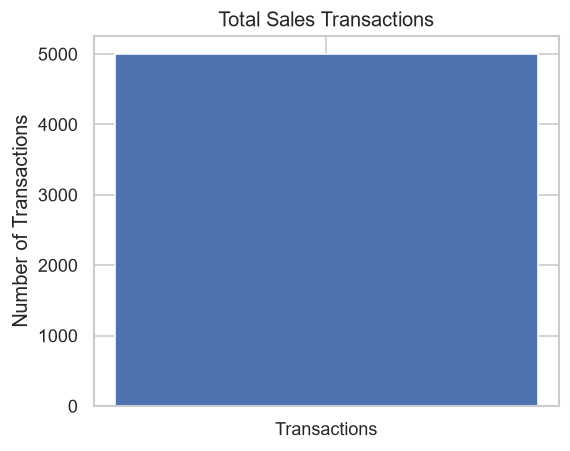

In [42]:
plt.figure(figsize=(5,4))

plt.bar(["Transactions"], [total_transactions])

plt.title("Total Sales Transactions")
plt.ylabel("Number of Transactions")

plt.show()

## Business Insight

The total number of transactions provides an overall measure of business activity and establishes the baseline for all subsequent analyses.

This KPI is frequently monitored to evaluate business growth over time.

# Question 2: How many sales transactions were processed by each store location?

## Business Objective

Management wants to determine the number of sales transactions processed by each store location and compare transaction volumes across all locations.

The results are sorted in descending order of transaction count, allowing management to identify which stores handle the highest and lowest number of sales transactions. This information supports operational planning, workforce allocation, and regional performance evaluation.

In [43]:
pipeline = [
    {
        "$group": {
            "_id": "$storeLocation",
            "Total Transactions": {"$sum": 1}
        }
    },
    {
        "$sort": {
            "Total Transactions": -1
        }
    }
]

store_transactions = list(sales.aggregate(pipeline))

store_df = pd.DataFrame(store_transactions)

store_df.rename(columns={"_id": "Store Location"}, inplace=True)

store_df

,Store Location,Total Transactions
0,Denver,1549
1,Seattle,1134
2,London,794
3,Austin,676
4,New York,501
5,San Diego,346


## Explanation

The aggregation pipeline performs two operations:

1. Groups all sales by **store location**.
2. Counts the number of transactions for each location.
3. Sorts the results in descending order.

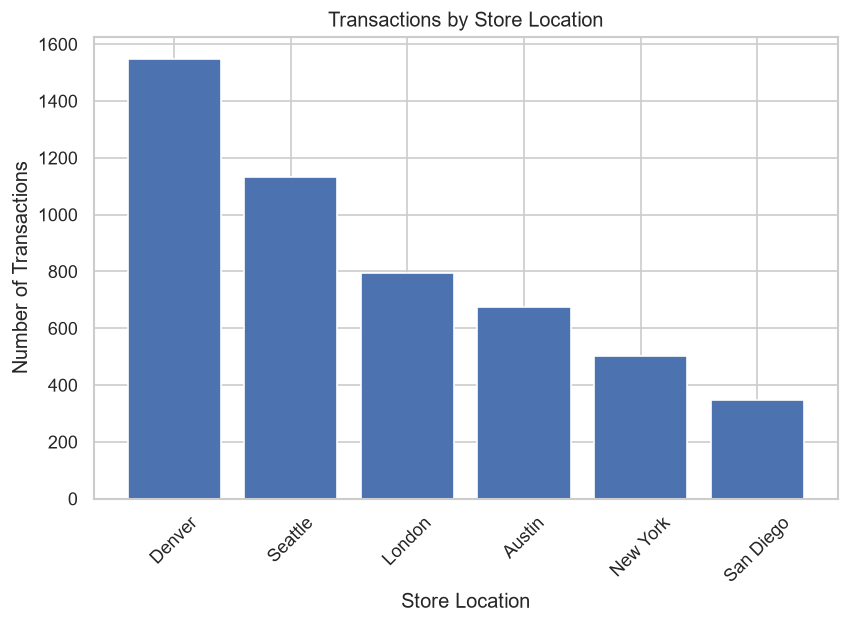

In [44]:
plt.figure(figsize=(8,5))

plt.bar(store_df["Store Location"],
        store_df["Total Transactions"])

plt.title("Transactions by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

## Business Insight

The results show the total number of sales transactions for each store location, ranked from the highest to the lowest transaction volume.

Stores with higher transaction counts generally experience greater customer activity and may require additional staffing, inventory, or operational resources. Conversely, stores with lower transaction volumes may warrant further investigation to identify potential opportunities for improving customer engagement or sales performance.

**Note:** This analysis measures the **number of transactions**, not **revenue** or **profit**. A store with fewer transactions may still generate higher revenue if its average order value is greater.

# Question 3: How many sales transactions were completed using each purchase method?

## Business Objective

The company offers multiple purchase methods, such as **In-store**, **Online**, and **Phone**. Management wants to determine the number of sales transactions completed through each purchase method and compare their usage across the business.

The results are sorted in descending order of transaction count, enabling management to identify the most and least frequently used purchase methods. This analysis helps evaluate customer purchasing preferences and supports decisions related to sales channel management and customer service.

In [45]:
pipeline = [
    {
        "$group": {
            "_id": "$purchaseMethod",
            "Transactions": {"$sum": 1}
        }
    },
    {
        "$sort": {
            "Transactions": -1
        }
    }
]

purchase_df = pd.DataFrame(list(sales.aggregate(pipeline)))

purchase_df.rename(columns={"_id":"Purchase Method"}, inplace=True)

purchase_df

,Purchase Method,Transactions
0,In store,2819
1,Online,1585
2,Phone,596


## Explanation

The aggregation groups transactions based on the purchase method and counts the number of transactions for each category.

## Business Insight

The analysis presents the total number of sales transactions for each purchase method, ranked from the highest to the lowest transaction volume.

Understanding the distribution of purchase methods helps the business identify customers' preferred sales channels. A purchase method with a significantly higher number of transactions indicates stronger customer adoption and may justify additional investment in infrastructure, staffing, or promotional activities. Conversely, methods with lower transaction volumes may require process improvements or targeted marketing efforts to increase customer engagement.

**Note:** This analysis compares the **number of transactions** for each purchase method. It does **not** compare the **revenue**, **profit**, or **average order value** associated with each purchase method.

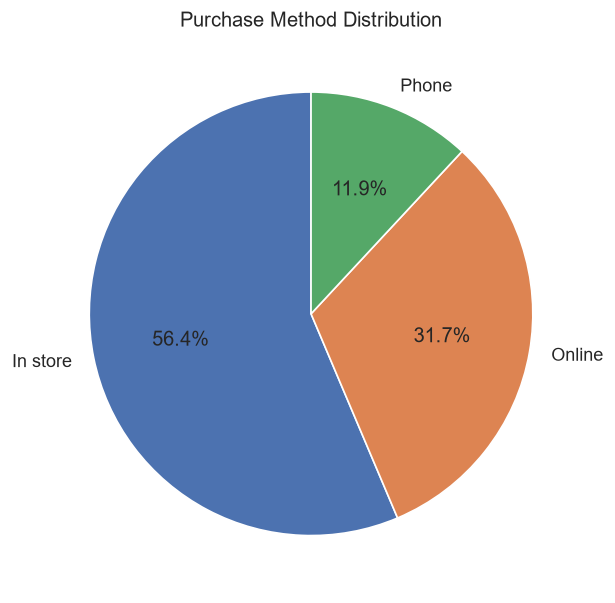

In [46]:
plt.figure(figsize=(6,6))

plt.pie(
    purchase_df["Transactions"],
    labels=purchase_df["Purchase Method"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Purchase Method Distribution")

plt.show()